In [2]:
import numpy as np
import pandas as pd
import glob
import os
import regex as re
import matplotlib.pyplot as plt

In [3]:
treated_malaria_df =  pd.read_csv("../../data_files/data/sivep_notification_data/treated_malaria_notification_data/malaria_vivax_treated.csv")
treated_malaria_df

,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME
0,2003-01-27,05/2003,21,210290,21.0,210055.0,29.0,1,2003-01-25,99.0,21.0,210055.0,29.0,2003-01-27
1,2003-03-20,12/2003,21,210232,21.0,210232.0,NaN,1,2003-03-18,11.0,21.0,210203.0,41.0,2003-03-20
2,2003-01-27,05/2003,21,210232,21.0,210203.0,55.0,1,2003-01-26,1.0,21.0,210203.0,55.0,2003-01-27
3,2003-09-30,40/2003,21,210232,21.0,210203.0,88.0,1,2003-09-26,1.0,21.0,210203.0,88.0,2003-09-30
4,2003-10-09,37/2003,21,210232,21.0,210203.0,88.0,1,2003-09-09,11.0,21.0,210203.0,88.0,2003-10-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3586495,2023-09-21,38/2023,21,210177,21.0,210177.0,5.0,1,2023-09-20,5.0,15.0,150360.0,NaN,2023-09-21
3586496,2023-10-13,41/2023,12,120045,13.0,130070.0,NaN,1,2023-11-01,7.0,13.0,130070.0,NaN,2023-10-13
3586497,2023-10-25,43/2023,14,140015,14.0,140010.0,1148.0,1,2023-10-23,2.0,14.0,140005.0,NaN,2023-10-25
3586498,2023-09-29,39/2023,16,160060,16.0,160060.0,32.0,1,2023-09-26,11.0,16.0,160027.0,NaN,2023-09-29


In [4]:
manaus_malaria_data = treated_malaria_df[treated_malaria_df['MUN_RESI'] == 130260.0]
manaus_malaria_data

,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME
6,2003-10-13,42/2003,13,130260,13.0,130260.0,564.0,1,2003-11-10,11.0,13.0,130260.0,564.0,2003-10-13
7,2003-10-10,41/2003,13,130260,13.0,130260.0,564.0,1,2003-10-10,11.0,13.0,130260.0,564.0,2003-10-10
8,2003-10-10,41/2003,13,130260,13.0,130260.0,564.0,1,2003-10-10,11.0,13.0,130260.0,564.0,2003-10-10
9,2003-03-25,13/2003,13,130260,13.0,130260.0,564.0,1,2003-03-22,99.0,13.0,130260.0,564.0,2003-03-25
10,2003-07-11,45/2003,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-07-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3586187,2023-05-30,22/2023,13,130260,13.0,130260.0,833.0,1,2023-05-26,10.0,11.0,110020.0,NaN,2023-05-30
3586214,2023-12-22,51/2023,11,110020,13.0,130260.0,NaN,1,2023-12-18,4.0,13.0,130260.0,NaN,2023-12-22
3586363,2023-12-26,52/2023,13,130260,13.0,130260.0,5.0,1,2023-12-23,11.0,14.0,140023.0,NaN,2023-12-26
3586380,2023-07-31,31/2023,13,130260,13.0,130260.0,222.0,1,2023-07-25,5.0,13.0,130406.0,NaN,2023-07-31


In [5]:
test = manaus_malaria_data[manaus_malaria_data['SINTOMAS'] == 2]
test

,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME
10,2003-07-11,45/2003,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-07-11
19,2003-11-24,48/2003,13,130260,13.0,130260.0,564.0,2,NaN,1.0,13.0,130260.0,564.0,2003-11-24
20,2003-12-12,50/2003,13,130260,13.0,130260.0,564.0,2,NaN,1.0,13.0,130260.0,564.0,2003-12-12
37,2003-10-11,46/2003,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-10-11
38,2003-09-23,38/3,13,130260,13.0,130260.0,564.0,2,NaN,11.0,13.0,130260.0,564.0,2003-09-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3584925,2023-04-08,31/2023,13,130260,13.0,130260.0,1077.0,2,NaN,11.0,13.0,130260.0,1077.0,2023-04-08
3584926,2023-10-11,45/2023,13,130260,13.0,130260.0,1077.0,2,NaN,11.0,13.0,130260.0,1077.0,2023-10-11
3584928,2023-10-11,45/2023,13,130260,13.0,130260.0,1077.0,2,NaN,1.0,13.0,130260.0,1077.0,2023-10-11
3584929,2023-10-20,42/2023,13,130260,13.0,130260.0,1077.0,2,NaN,11.0,13.0,130260.0,1077.0,2023-10-20


In [6]:
# Asymptomatic patients
asymptomatic_df = manaus_malaria_data[manaus_malaria_data['SINTOMAS'] == 2]

# Check for inconsistent rows:
# asymptomatic but symptom date exists
inconsistent_asymptomatic = asymptomatic_df[
    asymptomatic_df['DT_SINTO'].notna()
]

print("Number of inconsistent asymptomatic records:")
print(len(inconsistent_asymptomatic))

inconsistent_asymptomatic

Number of inconsistent asymptomatic records:
0


,DT_NOTIF,SEM_NOTI,UF_NOTIF,MUN_NOTI,UF_RESID,MUN_RESI,LOC_RESI,SINTOMAS,DT_SINTO,COD_OCUP,UF_INFEC,MUN_INFE,LOC_INFE,DT_EXAME


In [7]:
def aggregate_with_infectious_period(df, infectious_days=120):
    """
    Aggregate cases considering infectious period.
    Handles both symptomatic (DT_SINTO available) and asymptomatic cases.
    
    For asymptomatic cases (SINTOMAS = 2), we use DT_NOTIF as the infection start date.
    For symptomatic cases (SINTOMAS = 1), we use DT_SINTO.
    """
    
    # Make a copy
    df = df.copy()
    
    # Create a unified infection start date column
    # For symptomatic cases (SINTOMAS = 1): use DT_SINTO
    # For asymptomatic cases (SINTOMAS = 2): use DT_NOTIF
    # For other cases: use DT_NOTIF as fallback
    df['infection_start'] = df['DT_SINTO'].copy()
    
    # For asymptomatic or missing symptom date, use notification date
    asymptomatic_mask = (df['SINTOMAS'] == 2) | (df['DT_SINTO'].isna())
    df.loc[asymptomatic_mask, 'infection_start'] = df.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format for infection_start
    if df['infection_start'].dtype != 'datetime64[ns]':
        df['infection_start'] = pd.to_datetime(df['infection_start'], errors='coerce')
    
    # Drop only rows where infection_start is completely invalid (should be rare)
    df = df.dropna(subset=['infection_start'])
    
    print(f"Processing {len(df):,} cases")
    print(f"  - Symptomatic (using DT_SINTO): {(df['SINTOMAS'] == 1).sum():,}")
    print(f"  - Asymptomatic (using DT_NOTIF): {(df['SINTOMAS'] == 2).sum():,}")
    print(f"  - Other/Unknown: {((df['SINTOMAS'] != 1) & (df['SINTOMAS'] != 2)).sum():,}")
    
    # Create date range covering the entire period
    min_date = df['infection_start'].min()
    max_date = df['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    print(f"Date range: {min_date.date()} to {max_date.date()} ({len(date_range):,} days)")
    
    # Convert to numpy arrays for faster operations
    start_dates = df['infection_start'].values
    end_dates = start_dates + np.timedelta64(infectious_days, 'D')
    
    # Initialize array for active cases
    active_cases = np.zeros(len(date_range), dtype=int)
    
    # Process cases to count active days
    print("Calculating active cases...")
    for start, end in zip(start_dates, end_dates):
        mask = (date_range >= start) & (date_range < end)
        active_cases[mask] += 1
    
    # Create result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_cases': active_cases
    })
    
    print(f"Peak active cases: {active_cases.max():,}")
    print(f"Average active cases: {active_cases.mean():.1f}")
    
    return result_df

# Apply to your cleaned data
daily_active_cases = aggregate_with_infectious_period(manaus_malaria_data)

Processing 331,470 cases
  - Symptomatic (using DT_SINTO): 307,597
  - Asymptomatic (using DT_NOTIF): 23,873
  - Other/Unknown: 0
Date range: 2002-12-27 to 2024-04-27 (7,793 days)
Calculating active cases...
Peak active cases: 18,789
Average active cases: 5104.1


In [8]:
def aggregate_with_infectious_period_detailed(df, infectious_days=120):
    """
    Detailed aggregation tracking symptomatic and asymptomatic cases separately.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Create infection start date based on symptomatology
    df['infection_start'] = df['DT_SINTO'].copy()
    asymptomatic_mask = (df['SINTOMAS'] == 2) | (df['DT_SINTO'].isna())
    df.loc[asymptomatic_mask, 'infection_start'] = df.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Drop only completely invalid rows
    df = df.dropna(subset=['infection_start'])
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df[df['SINTOMAS'] == 1].copy()
    asymptomatic_df = df[df['SINTOMAS'] == 2].copy()
    
    print(f"Total cases: {len(df):,}")
    print(f"  - Symptomatic: {len(symptomatic_df):,}")
    print(f"  - Asymptomatic: {len(asymptomatic_df):,}")
    
    # Create date range
    min_date = df['infection_start'].min()
    max_date = df['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    # Function to count active cases for a subset
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        for start, end in zip(start_dates, end_dates):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
        
        return active
    
    # Count active cases for each group
    print("Calculating active cases...")
    active_symptomatic = count_active(symptomatic_df)
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create detailed result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    print(f"\nResults:")
    print(f"  Peak total active: {active_total.max():,}")
    print(f"  Peak symptomatic: {active_symptomatic.max():,}")
    print(f"  Peak asymptomatic: {active_asymptomatic.max():,}")
    
    return result_df

# Apply detailed version
daily_active_cases_detailed = aggregate_with_infectious_period_detailed(manaus_malaria_data)

Total cases: 331,470
  - Symptomatic: 307,597
  - Asymptomatic: 23,873
Calculating active cases...

Results:
  Peak total active: 18,789
  Peak symptomatic: 17,839
  Peak asymptomatic: 1,684


Original data range: 2002-12-27 00:00:00 to 2024-04-27 00:00:00
Trimmed data range: 2003-04-26 00:00:00 to 2024-04-27 00:00:00
Rows removed: 120
Remaining rows: 7,673


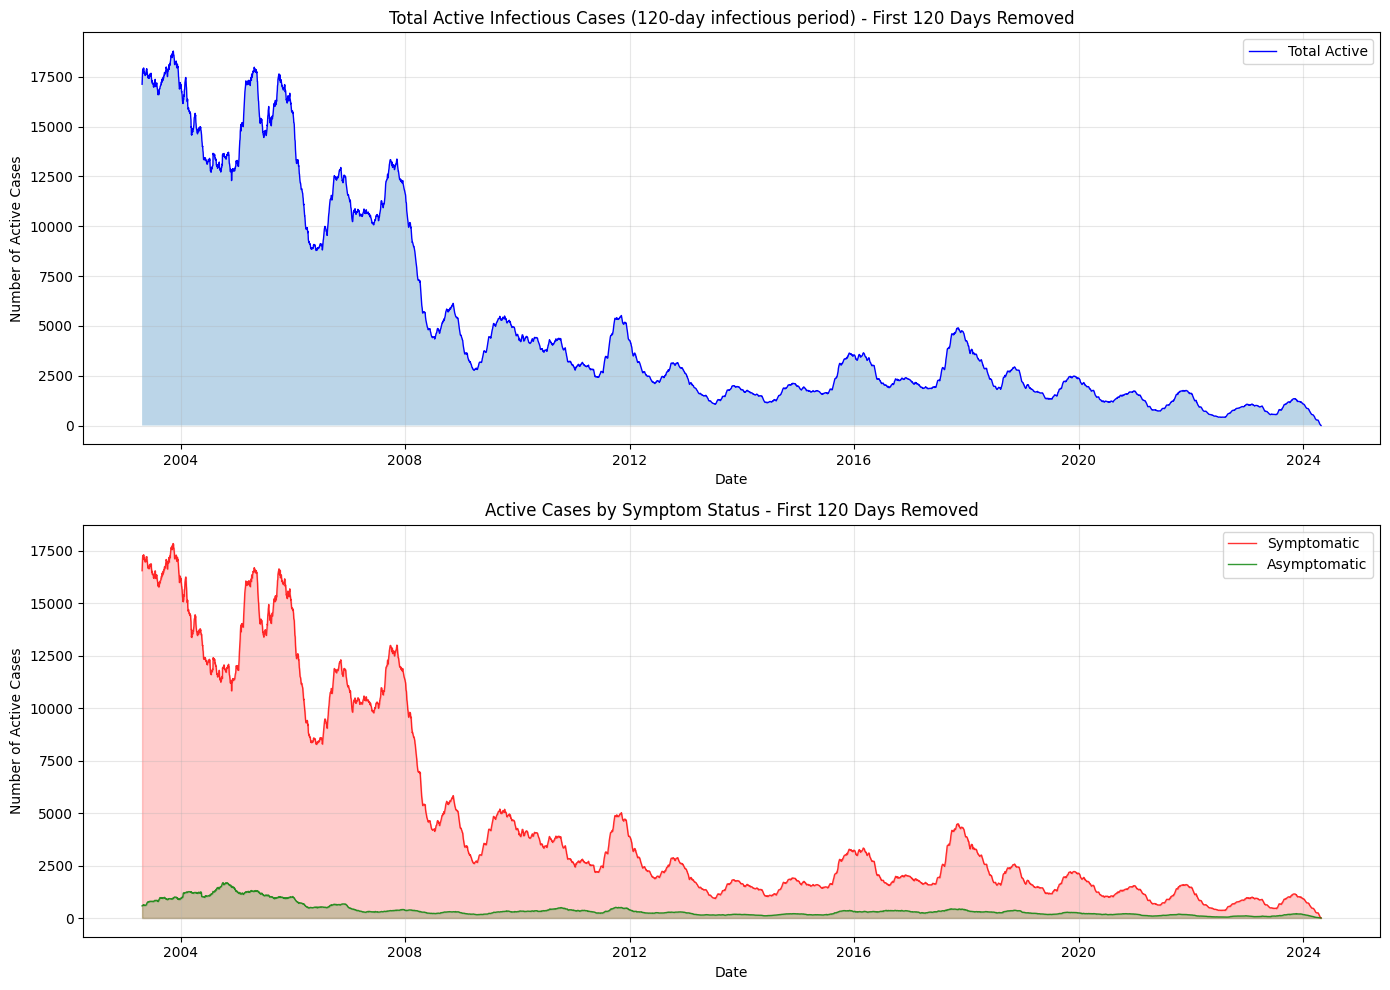


=== SUMMARY STATISTICS (First 120 Days Removed) ===
Period: 2003-04-26 to 2024-04-27

Active Cases Statistics (trimmed):
  Average daily active: 5067
  Peak daily active: 18,789
  Peak date: 2003-11-15


In [9]:
# After creating daily_active_cases_detailed, drop the first 120 days

# Remove the first 120 days to eliminate the artificial ramp-up period
daily_active_cases_detailed_trimmed = daily_active_cases_detailed.iloc[120:].reset_index(drop=True)

print(f"Original data range: {daily_active_cases_detailed['date'].min()} to {daily_active_cases_detailed['date'].max()}")
print(f"Trimmed data range: {daily_active_cases_detailed_trimmed['date'].min()} to {daily_active_cases_detailed_trimmed['date'].max()}")
print(f"Rows removed: 120")
print(f"Remaining rows: {len(daily_active_cases_detailed_trimmed):,}")

# Plot the trimmed results
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot total active cases (trimmed)
axes[0].plot(daily_active_cases_detailed_trimmed['date'], 
             daily_active_cases_detailed_trimmed['active_total'], 
             color='blue', linewidth=1, label='Total Active')
axes[0].fill_between(daily_active_cases_detailed_trimmed['date'], 0, 
                     daily_active_cases_detailed_trimmed['active_total'], alpha=0.3)
axes[0].set_title('Total Active Infectious Cases (120-day infectious period) - First 120 Days Removed')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Active Cases')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot symptomatic vs asymptomatic (trimmed)
axes[1].plot(daily_active_cases_detailed_trimmed['date'], 
             daily_active_cases_detailed_trimmed['active_symptomatic'], 
             color='red', linewidth=1, label='Symptomatic', alpha=0.8)
axes[1].plot(daily_active_cases_detailed_trimmed['date'], 
             daily_active_cases_detailed_trimmed['active_asymptomatic'], 
             color='green', linewidth=1, label='Asymptomatic', alpha=0.8)
axes[1].fill_between(daily_active_cases_detailed_trimmed['date'], 0, 
                     daily_active_cases_detailed_trimmed['active_symptomatic'], 
                     color='red', alpha=0.2)
axes[1].fill_between(daily_active_cases_detailed_trimmed['date'], 0, 
                     daily_active_cases_detailed_trimmed['active_asymptomatic'], 
                     color='green', alpha=0.2)
axes[1].set_title('Active Cases by Symptom Status - First 120 Days Removed')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Active Cases')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics for trimmed data
print("\n=== SUMMARY STATISTICS (First 120 Days Removed) ===")
print(f"Period: {daily_active_cases_detailed_trimmed['date'].min().date()} to {daily_active_cases_detailed_trimmed['date'].max().date()}")
print(f"\nActive Cases Statistics (trimmed):")
print(f"  Average daily active: {daily_active_cases_detailed_trimmed['active_total'].mean():.0f}")
print(f"  Peak daily active: {daily_active_cases_detailed_trimmed['active_total'].max():,}")
print(f"  Peak date: {daily_active_cases_detailed_trimmed.loc[daily_active_cases_detailed_trimmed['active_total'].idxmax(), 'date'].date()}")

In [10]:
def aggregate_with_infectious_period_and_carryover(df, infectious_days=120, start_year=2017, end_year=2024):
    """
    Aggregate cases considering infectious period, including carryover from previous year.
    Handles both symptomatic and asymptomatic cases.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Include previous year for carryover calculation
    df_extended = df[(df['DT_NOTIF'].dt.year >= start_year - 1) & 
                     (df['DT_NOTIF'].dt.year <= end_year)].copy()
    
    print(f"\n=== Processing {start_year}-{end_year} Data (with carryover from {start_year-1}) ===")
    print(f"Total cases in extended range: {len(df_extended):,}")
    
    # Create a unified infection start date column
    df_extended['infection_start'] = df_extended['DT_SINTO'].copy()
    
    # For asymptomatic or missing symptom date, use notification date
    asymptomatic_mask = (df_extended['SINTOMAS'] == 2) | (df_extended['DT_SINTO'].isna())
    df_extended.loc[asymptomatic_mask, 'infection_start'] = df_extended.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format for infection_start
    if df_extended['infection_start'].dtype != 'datetime64[ns]':
        df_extended['infection_start'] = pd.to_datetime(df_extended['infection_start'], errors='coerce')
    
    # Drop only rows where infection_start is completely invalid
    df_extended = df_extended.dropna(subset=['infection_start'])
    
    print(f"Valid cases after processing: {len(df_extended):,}")
    print(f"  - Symptomatic (using DT_SINTO): {(df_extended['SINTOMAS'] == 1).sum():,}")
    print(f"  - Asymptomatic (using DT_NOTIF): {(df_extended['SINTOMAS'] == 2).sum():,}")
    
    # Create date range covering the entire period
    min_date = df_extended['infection_start'].min()
    max_date = df_extended['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    print(f"\nDate range: {min_date.date()} to {max_date.date()} ({len(date_range):,} days)")
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df_extended[df_extended['SINTOMAS'] == 1].copy()
    asymptomatic_df = df_extended[df_extended['SINTOMAS'] == 2].copy()
    
    # Function to count active cases for a subset
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        for start, end in zip(start_dates, end_dates):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
        
        return active
    
    # Count active cases for each group
    print("\nCalculating active cases...")
    active_symptomatic = count_active(symptomatic_df)
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create detailed result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    # Filter to only show results from start_year onward
    result_df_filtered = result_df[result_df['date'].dt.year >= start_year].copy()
    result_df_filtered = result_df_filtered.reset_index(drop=True)
    
    # Find peak date
    if len(result_df_filtered) > 0:
        peak_idx = result_df_filtered['active_total'].idxmax()
        peak_date = result_df_filtered.loc[peak_idx, 'date']
        
        print(f"\n=== Results for {start_year}-{end_year} (including carryover) ===")
        print(f"  Average daily active: {result_df_filtered['active_total'].mean():.0f}")
        print(f"  Peak total active: {result_df_filtered['active_total'].max():,}")
        print(f"  Peak symptomatic: {result_df_filtered['active_symptomatic'].max():,}")
        print(f"  Peak asymptomatic: {result_df_filtered['active_asymptomatic'].max():,}")
        print(f"  Peak date: {peak_date.date()}")
        print(f"  Active cases on first day ({result_df_filtered['date'].min().date()}): {result_df_filtered['active_total'].iloc[0]:,}")
    
    return result_df_filtered

# Apply with carryover from 2015
daily_active_cases_2017_2024_with_carryover = aggregate_with_infectious_period_and_carryover(
    manaus_malaria_data, 
    infectious_days=120, 
    start_year=2017, 
    end_year=2024
)


=== Processing 2017-2024 Data (with carryover from 2016) ===
Total cases in extended range: 43,918
Valid cases after processing: 43,918
  - Symptomatic (using DT_SINTO): 38,740
  - Asymptomatic (using DT_NOTIF): 5,178

Date range: 2015-12-17 to 2024-04-27 (3,055 days)

Calculating active cases...

=== Results for 2017-2024 (including carryover) ===
  Average daily active: 1687
  Peak total active: 4,897
  Peak symptomatic: 4,486
  Peak asymptomatic: 437
  Peak date: 2017-11-09
  Active cases on first day (2017-01-01): 2,273


In [11]:
def aggregate_with_prior_period(df, infectious_days=120, start_year=2017, end_year=2023):
    """
    Aggregate cases considering infectious period, including cases from prior period.
    This ensures accurate active case counts at the beginning of the study period.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Calculate the start date for prior period (120 days before start_year)
    prior_start_date = pd.Timestamp(year=start_year, month=1, day=1) - pd.Timedelta(days=infectious_days)
    
    # Include prior period cases (from start_year-1 to ensure we capture all that could be active)
    # Actually, we need cases that could still be infectious on Jan 1 of start_year
    df_extended = df[(df['DT_NOTIF'] >= prior_start_date) & (df['DT_NOTIF'].dt.year <= end_year)].copy()
    
    print(f"\n=== Processing {start_year}-{end_year} with {infectious_days} days prior ===")
    print(f"Prior period start: {prior_start_date.date()}")
    print(f"Total cases in extended range: {len(df_extended):,}")
    print(f"  - Cases from prior period ({prior_start_date.year}): {(df_extended['DT_NOTIF'].dt.year == prior_start_date.year).sum():,}")
    
    # Create a unified infection start date column
    df_extended['infection_start'] = df_extended['DT_SINTO'].copy()
    
    # For asymptomatic or missing symptom date, use notification date
    asymptomatic_mask = (df_extended['SINTOMAS'] == 2) | (df_extended['DT_SINTO'].isna())
    df_extended.loc[asymptomatic_mask, 'infection_start'] = df_extended.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format for infection_start
    if df_extended['infection_start'].dtype != 'datetime64[ns]':
        df_extended['infection_start'] = pd.to_datetime(df_extended['infection_start'], errors='coerce')
    
    # Drop only rows where infection_start is completely invalid
    df_extended = df_extended.dropna(subset=['infection_start'])
    
    print(f"Valid cases after processing: {len(df_extended):,}")
    print(f"  - Symptomatic (using DT_SINTO): {(df_extended['SINTOMAS'] == 1).sum():,}")
    print(f"  - Asymptomatic (using DT_NOTIF): {(df_extended['SINTOMAS'] == 2).sum():,}")
    
    # Create date range covering the entire period (from prior_start_date to end)
    min_date = df_extended['infection_start'].min()
    max_date = df_extended['infection_start'].max() + pd.Timedelta(days=infectious_days)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    print(f"\nDate range: {min_date.date()} to {max_date.date()} ({len(date_range):,} days)")
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df_extended[df_extended['SINTOMAS'] == 1].copy()
    asymptomatic_df = df_extended[df_extended['SINTOMAS'] == 2].copy()
    
    # Function to count active cases for a subset
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        print(f"    Processing {len(subset_df):,} cases...")
        for i, (start, end) in enumerate(zip(start_dates, end_dates)):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
            
            # Print progress every 50,000 cases
            if (i + 1) % 50000 == 0:
                print(f"      Processed {i+1:,}/{len(subset_df):,} cases")
        
        return active
    
    # Count active cases for each group
    print("\nCalculating active cases...")
    print("  Processing symptomatic cases...")
    active_symptomatic = count_active(symptomatic_df)
    print("  Processing asymptomatic cases...")
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create detailed result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    # Filter to only show results from start_year onward
    result_df_filtered = result_df[result_df['date'].dt.year >= start_year].copy()
    result_df_filtered = result_df_filtered.reset_index(drop=True)
    
    # Find peak date
    if len(result_df_filtered) > 0:
        peak_idx = result_df_filtered['active_total'].idxmax()
        peak_date = result_df_filtered.loc[peak_idx, 'date']
        
        print(f"\n=== Results for {start_year}-{end_year} (including {infectious_days}-day prior period) ===")
        print(f"  Average daily active: {result_df_filtered['active_total'].mean():.0f}")
        print(f"  Peak total active: {result_df_filtered['active_total'].max():,}")
        print(f"  Peak symptomatic: {result_df_filtered['active_symptomatic'].max():,}")
        print(f"  Peak asymptomatic: {result_df_filtered['active_asymptomatic'].max():,}")
        print(f"  Peak date: {peak_date.date()}")
        print(f"  Active cases on first day ({result_df_filtered['date'].min().date()}): {result_df_filtered['active_total'].iloc[0]:,}")
    
    return result_df_filtered

# # Apply with 120 days prior to 2017
# daily_active_cases_2017_2023_with_prior = aggregate_with_prior_period(
#     manaus_malaria_data, 
#     infectious_days=120, 
#     start_year=2017, 
#     end_year=2023
# )

# Apply with 120 days prior to 2017
daily_active_cases_2017_2023_with_prior = aggregate_with_prior_period(
    manaus_malaria_data, 
    infectious_days=120, 
    start_year=2017, 
    end_year=2023
)


=== Processing 2017-2023 with 120 days prior ===
Prior period start: 2016-09-03
Total cases in extended range: 38,817
  - Cases from prior period (2016): 2,280
Valid cases after processing: 38,817
  - Symptomatic (using DT_SINTO): 34,313
  - Asymptomatic (using DT_NOTIF): 4,504

Date range: 2016-08-27 to 2024-04-27 (2,801 days)

Calculating active cases...
  Processing symptomatic cases...
    Processing 34,313 cases...
  Processing asymptomatic cases...
    Processing 4,504 cases...

=== Results for 2017-2023 (including 120-day prior period) ===
  Average daily active: 1687
  Peak total active: 4,897
  Peak symptomatic: 4,486
  Peak asymptomatic: 437
  Peak date: 2017-11-09
  Active cases on first day (2017-01-01): 2,266


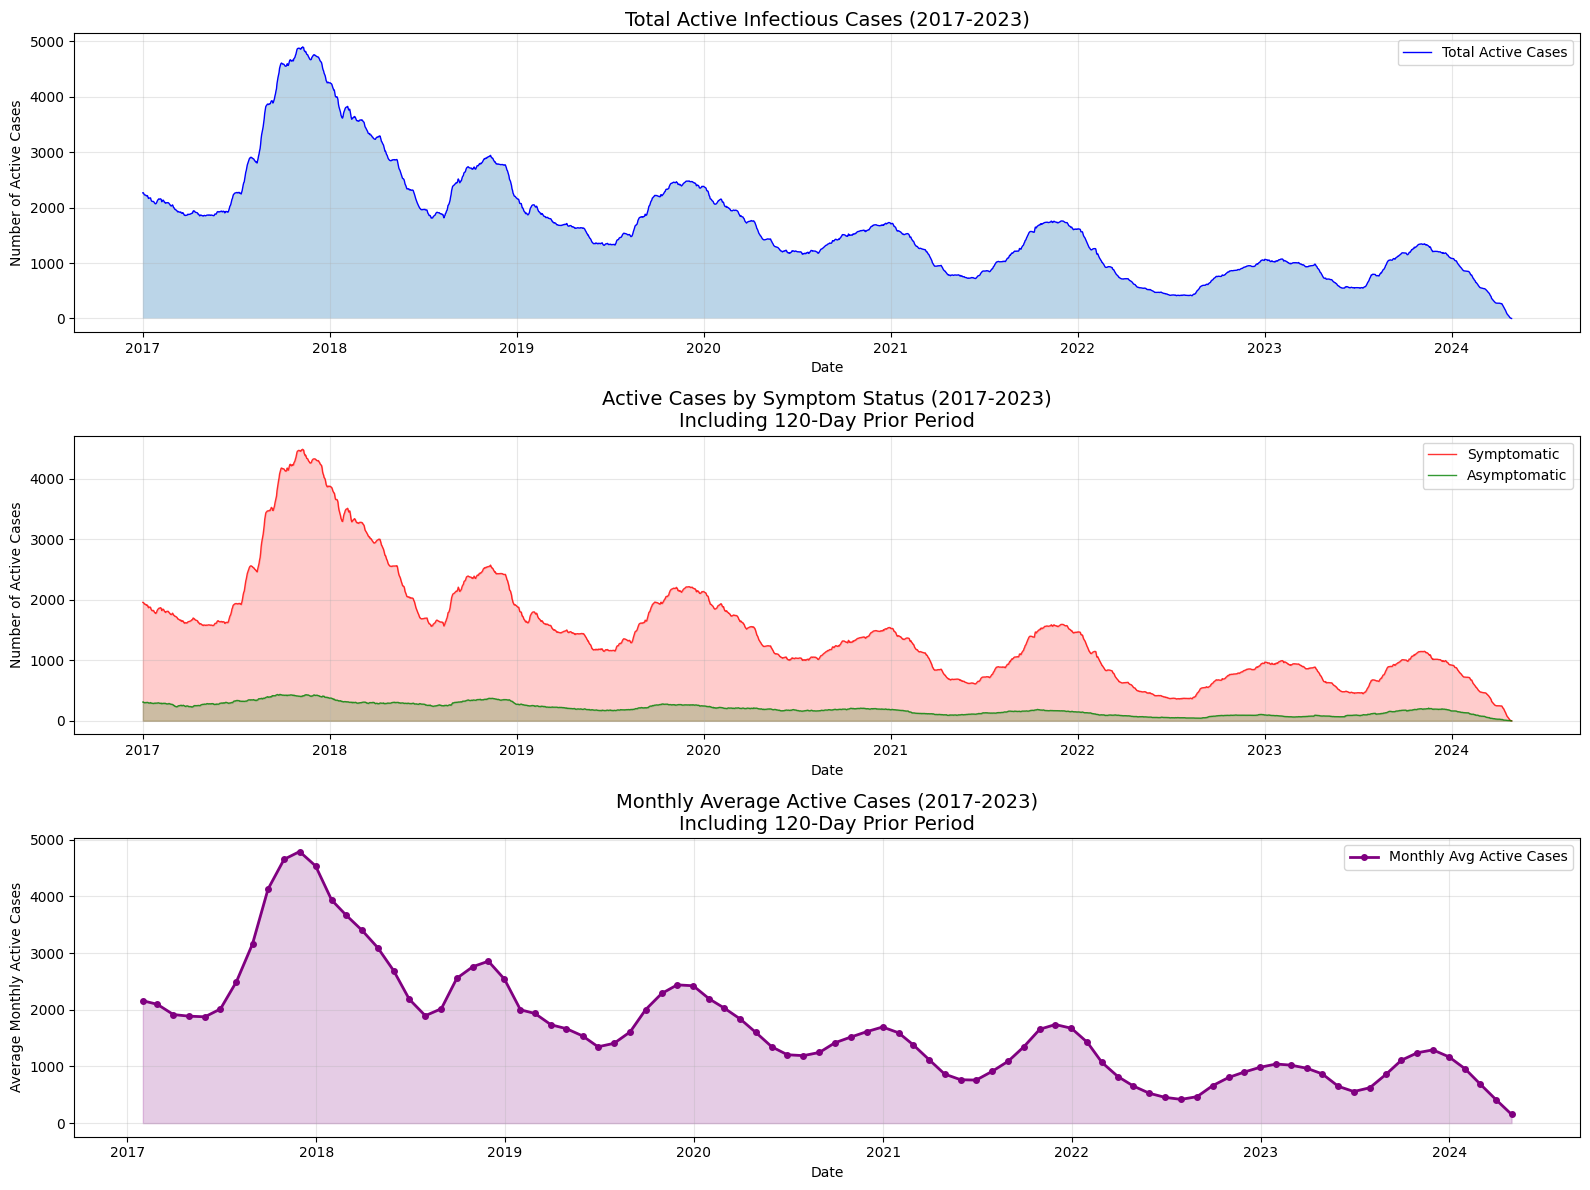

In [12]:
# Plot the results
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Total active cases
axes[0].plot(daily_active_cases_2017_2023_with_prior['date'], 
             daily_active_cases_2017_2023_with_prior['active_total'], 
             color='blue', linewidth=1, label='Total Active Cases')
axes[0].fill_between(daily_active_cases_2017_2023_with_prior['date'], 0, 
                     daily_active_cases_2017_2023_with_prior['active_total'], alpha=0.3)
#axes[0].set_title('Total Active Infectious Cases (2017-2023, 120-day infectious period)\nIncluding 120-Day Prior Period', fontsize=14)
axes[0].set_title('Total Active Infectious Cases (2017-2023)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Active Cases')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Symptomatic vs Asymptomatic
axes[1].plot(daily_active_cases_2017_2023_with_prior['date'], 
             daily_active_cases_2017_2023_with_prior['active_symptomatic'], 
             color='red', linewidth=1, label='Symptomatic', alpha=0.8)
axes[1].plot(daily_active_cases_2017_2023_with_prior['date'], 
             daily_active_cases_2017_2023_with_prior['active_asymptomatic'], 
             color='green', linewidth=1, label='Asymptomatic', alpha=0.8)
axes[1].fill_between(daily_active_cases_2017_2023_with_prior['date'], 0, 
                     daily_active_cases_2017_2023_with_prior['active_symptomatic'], 
                     color='red', alpha=0.2)
axes[1].fill_between(daily_active_cases_2017_2023_with_prior['date'], 0, 
                     daily_active_cases_2017_2023_with_prior['active_asymptomatic'], 
                     color='green', alpha=0.2)
axes[1].set_title('Active Cases by Symptom Status (2017-2023)\nIncluding 120-Day Prior Period', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Active Cases')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: Monthly averages
# Resample to monthly for smoother view
monthly_avg = daily_active_cases_2017_2023_with_prior.set_index('date').resample('ME').mean()

axes[2].plot(monthly_avg.index, monthly_avg['active_total'], 
             color='purple', linewidth=2, marker='o', markersize=4, label='Monthly Avg Active Cases')
axes[2].fill_between(monthly_avg.index, 0, monthly_avg['active_total'], alpha=0.2, color='purple')
axes[2].set_title('Monthly Average Active Cases (2017-2023)\nIncluding 120-Day Prior Period', fontsize=14)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Average Monthly Active Cases')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [13]:
# Ensure DT_NOTIF is datetime
if manaus_malaria_data['DT_NOTIF'].dtype != 'datetime64[ns]':
    manaus_malaria_data['DT_NOTIF'] = pd.to_datetime(manaus_malaria_data['DT_NOTIF'], errors='coerce')
    print("Converted DT_NOTIF to datetime")

# Verify the conversion
print(f"DT_NOTIF dtype: {manaus_malaria_data['DT_NOTIF'].dtype}")
print(f"DT_NOTIF sample:\n{manaus_malaria_data['DT_NOTIF'].head()}")

Converted DT_NOTIF to datetime
DT_NOTIF dtype: datetime64[us]
DT_NOTIF sample:
6    2003-10-13
7    2003-10-10
8    2003-10-10
9    2003-03-25
10   2003-07-11
Name: DT_NOTIF, dtype: datetime64[us]


In [14]:
def calculate_active_cases_with_prior_period(df, infectious_days=120, start_year=2017, end_year=2023):
    """
    Calculate active cases including prior period for accurate initial counts,
    then trim the first infectious_days days.
    """
    
    # Make a copy
    df = df.copy()
    
    # Ensure datetime for date columns
    date_columns = ['DT_SINTO', 'DT_NOTIF']
    for col in date_columns:
        if col in df.columns and df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Calculate the start date (120 days before start_year)
    prior_start_date = pd.Timestamp(year=start_year, month=1, day=1) - pd.Timedelta(days=infectious_days)
    end_date = pd.Timestamp(year=end_year, month=12, day=31) + pd.Timedelta(days=infectious_days)
    
    # Include prior period cases
    df_extended = df[(df['DT_NOTIF'] >= prior_start_date) & (df['DT_NOTIF'] <= end_date)].copy()
    
    print(f"\n=== Including {infectious_days} days prior to {start_year} ===")
    print(f"Prior period start: {prior_start_date.date()}")
    print(f"Total cases in extended range: {len(df_extended):,}")
    print(f"  - Cases from prior period: {(df_extended['DT_NOTIF'] < pd.Timestamp(year=start_year, month=1, day=1)).sum():,}")
    
    # Create unified infection start date
    df_extended['infection_start'] = df_extended['DT_SINTO'].copy()
    asymptomatic_mask = (df_extended['SINTOMAS'] == 2) | (df_extended['DT_SINTO'].isna())
    df_extended.loc[asymptomatic_mask, 'infection_start'] = df_extended.loc[asymptomatic_mask, 'DT_NOTIF']
    
    # Ensure datetime format
    if df_extended['infection_start'].dtype != 'datetime64[ns]':
        df_extended['infection_start'] = pd.to_datetime(df_extended['infection_start'], errors='coerce')
    
    df_extended = df_extended.dropna(subset=['infection_start'])
    
    # Create date range from prior_start_date to end
    date_range = pd.date_range(start=prior_start_date, end=end_date, freq='D')
    
    print(f"\nDate range: {date_range.min().date()} to {date_range.max().date()} ({len(date_range):,} days)")
    
    # Separate symptomatic and asymptomatic
    symptomatic_df = df_extended[df_extended['SINTOMAS'] == 1].copy()
    asymptomatic_df = df_extended[df_extended['SINTOMAS'] == 2].copy()
    
    # Function to count active cases
    def count_active(subset_df):
        if len(subset_df) == 0:
            return np.zeros(len(date_range), dtype=int)
        
        start_dates = subset_df['infection_start'].values
        end_dates = start_dates + np.timedelta64(infectious_days, 'D')
        active = np.zeros(len(date_range), dtype=int)
        
        for start, end in zip(start_dates, end_dates):
            mask = (date_range >= start) & (date_range < end)
            active[mask] += 1
        
        return active
    
    # Count active cases
    print("\nCalculating active cases...")
    active_symptomatic = count_active(symptomatic_df)
    active_asymptomatic = count_active(asymptomatic_df)
    active_total = active_symptomatic + active_asymptomatic
    
    # Create result dataframe
    result_df = pd.DataFrame({
        'date': date_range,
        'active_total': active_total,
        'active_symptomatic': active_symptomatic,
        'active_asymptomatic': active_asymptomatic
    })
    
    return result_df

# Calculate active cases including prior period
daily_active_cases_2012_2015 = calculate_active_cases_with_prior_period(
    manaus_malaria_data, 
    infectious_days=120, 
    start_year=2012, 
    end_year=2015
)

daily_active_cases_2017_2023 = calculate_active_cases_with_prior_period(
    manaus_malaria_data, 
    infectious_days=120, 
    start_year=2017, 
    end_year=2023
)


=== Including 120 days prior to 2012 ===
Prior period start: 2011-09-03
Total cases in extended range: 32,439
  - Cases from prior period: 4,279

Date range: 2011-09-03 to 2016-04-29 (1,701 days)

Calculating active cases...

=== Including 120 days prior to 2017 ===
Prior period start: 2016-09-03
Total cases in extended range: 38,817
  - Cases from prior period: 2,280

Date range: 2016-09-03 to 2024-04-29 (2,796 days)

Calculating active cases...


In [15]:
# Calculate new cases per day based on infection start
# First, create a function to get infection start for all cases
def get_infection_start(row):
    if row['SINTOMAS'] == 2 or pd.isna(row['DT_SINTO']):
        return row['DT_NOTIF']
    else:
        return row['DT_SINTO']

# Apply to get infection start for all cases in Manaus
manaus_malaria_data_with_start = manaus_malaria_data.copy()
manaus_malaria_data_with_start['infection_start'] = manaus_malaria_data_with_start.apply(get_infection_start, axis=1)

# Ensure datetime
if manaus_malaria_data_with_start['infection_start'].dtype != 'datetime64[ns]':
    manaus_malaria_data_with_start['infection_start'] = pd.to_datetime(
        manaus_malaria_data_with_start['infection_start'], errors='coerce'
    )

# Calculate new cases per day (based on infection start)
daily_new_cases_2012_2015 = manaus_malaria_data_with_start.groupby(
    manaus_malaria_data_with_start['infection_start'].dt.floor('D')
).size()

# Reindex to match full date range
daily_new_cases_2012_2015 = daily_new_cases_2012_2015.reindex(daily_active_cases_2012_2015['date'], fill_value=0)

# Add new cases and cumulative cases to the full dataframe
daily_active_cases_2012_2015['new_cases'] = daily_new_cases_2012_2015.values
daily_active_cases_2012_2015['cumulative_cases'] = daily_new_cases_2012_2015.cumsum().values

#################################

# Calculate new cases per day (based on infection start)
daily_new_cases_2017_2023 = manaus_malaria_data_with_start.groupby(
    manaus_malaria_data_with_start['infection_start'].dt.floor('D')
).size()

# Reindex to match full date range
daily_new_cases_2017_2023 = daily_new_cases_2017_2023.reindex(daily_active_cases_2017_2023['date'], fill_value=0)


# Add new cases and cumulative cases to the full dataframe
daily_active_cases_2017_2023['new_cases'] = daily_new_cases_2017_2023.values
daily_active_cases_2017_2023['cumulative_cases'] = daily_new_cases_2017_2023.cumsum().values

#################################

print(f"\nFull data range: {daily_active_cases_2017_2023['date'].min().date()} to {daily_active_cases_2017_2023['date'].max().date()}")
print(f"Total cumulative cases (full range): {daily_active_cases_2017_2023['cumulative_cases'].max():,.0f}")


Full data range: 2016-09-03 to 2024-04-29
Total cumulative cases (full range): 38,813


In [16]:
# Trim the first 120 days (the prior period)
daily_active_cases_trimmed_2012_2015 = daily_active_cases_2012_2015.iloc[120:].reset_index(drop=True)

print(f"\n=== After Trimming First 120 Days ===")
print(f"Original rows: {len(daily_active_cases_trimmed_2012_2015)}")
print(f"Trimmed rows: {len(daily_active_cases_trimmed_2012_2015)}")
print(f"Trimmed date range: {daily_active_cases_trimmed_2012_2015['date'].min().date()} to {daily_active_cases_trimmed_2012_2015['date'].max().date()}")
print(f"Active cases on first trimmed day: {daily_active_cases_trimmed_2012_2015['active_total'].iloc[0]:,.0f}")


=== After Trimming First 120 Days ===
Original rows: 1581
Trimmed rows: 1581
Trimmed date range: 2012-01-01 to 2016-04-29
Active cases on first trimmed day: 4,252


In [17]:
# Trim the first 120 days (the prior period)
daily_active_cases_trimmed_2017_2023 = daily_active_cases_2017_2023.iloc[120:].reset_index(drop=True)

print(f"\n=== After Trimming First 120 Days ===")
print(f"Original rows: {len(daily_active_cases_2017_2023)}")
print(f"Trimmed rows: {len(daily_active_cases_trimmed_2017_2023)}")
print(f"Trimmed date range: {daily_active_cases_trimmed_2017_2023['date'].min().date()} to {daily_active_cases_trimmed_2017_2023['date'].max().date()}")
print(f"Active cases on first trimmed day: {daily_active_cases_trimmed_2017_2023['active_total'].iloc[0]:,.0f}")


=== After Trimming First 120 Days ===
Original rows: 2796
Trimmed rows: 2676
Trimmed date range: 2017-01-01 to 2024-04-29
Active cases on first trimmed day: 2,266


In [18]:
# Check the first few days of 2017
jan_2017 = daily_active_cases_trimmed_2017_2023[
    (daily_active_cases_trimmed_2017_2023['date'] >= '2017-01-01') & 
    (daily_active_cases_trimmed_2017_2023['date'] <= '2017-01-10')
]

print("\n=== Active Cases at Beginning of 2017 (After Trimming) ===")
print(jan_2017[['date', 'active_total', 'new_cases', 'cumulative_cases']].head(10))

# Compare with the old approach that started at 2017-01-01
print(f"\nActive cases on Jan 1, 2017 (with prior period): {daily_active_cases_trimmed_2017_2023[daily_active_cases_trimmed_2017_2023['date'] == '2017-01-01']['active_total'].iloc[0]:,.0f}")


=== Active Cases at Beginning of 2017 (After Trimming) ===
        date  active_total  new_cases  cumulative_cases
0 2017-01-01          2266          2              2286
1 2017-01-02          2267          4              2290
2 2017-01-03          2247          5              2295
3 2017-01-04          2229          1              2296
4 2017-01-05          2228          0              2296
5 2017-01-06          2226          8              2304
6 2017-01-07          2220          2              2306
7 2017-01-08          2210          2              2308
8 2017-01-09          2216         12              2320
9 2017-01-10          2215          0              2320

Active cases on Jan 1, 2017 (with prior period): 2,266


In [19]:
# Create final dataframe with all metrics
final_df_2012_2015 = daily_active_cases_trimmed_2012_2015.copy()

# Add year, month, week columns for easier analysis
final_df_2012_2015['year'] = final_df_2012_2015['date'].dt.year
final_df_2012_2015['month'] = final_df_2012_2015['date'].dt.month
final_df_2012_2015['week'] = final_df_2012_2015['date'].dt.isocalendar().week
final_df_2012_2015['day_of_year'] = final_df_2012_2015['date'].dt.dayofyear

# Calculate additional metrics
final_df_2012_2015['active_per_new_case'] = final_df_2012_2015['active_total'] / (final_df_2012_2015['new_cases'] + 1)

# Save the final dataframe
final_df_2012_2015.to_csv("../../data_files/data/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2012_2015.csv", index=False)
print(f"\nSaved final dataframe: active_cases_2012_2015_with_cumulative.csv")
print(f"File has {len(final_df_2012_2015):,} rows and {len(final_df_2012_2015.columns)} columns")

# Preview
print("\nFirst 10 rows of final dataframe:")
print(final_df_2012_2015[['date', 'new_cases', 'active_total', 'cumulative_cases']].head(10))

print("\nLast 10 rows of final dataframe:")
print(final_df_2012_2015[['date', 'new_cases', 'active_total', 'cumulative_cases']].tail(10))


Saved final dataframe: active_cases_2012_2015_with_cumulative.csv
File has 1,581 rows and 11 columns

First 10 rows of final dataframe:
        date  new_cases  active_total  cumulative_cases
0 2012-01-01          9          4252              4277
1 2012-01-02          8          4257              4285
2 2012-01-03          2          4247              4287
3 2012-01-04          3          4240              4290
4 2012-01-05          0          4227              4290
5 2012-01-06          3          4197              4293
6 2012-01-07          6          4167              4299
7 2012-01-08         10          4147              4309
8 2012-01-09          5          4122              4314
9 2012-01-10          8          4123              4322

Last 10 rows of final dataframe:
           date  new_cases  active_total  cumulative_cases
1571 2016-04-20         31          3027             32325
1572 2016-04-21         23          3019             32348
1573 2016-04-22         14          

In [20]:
# Create final dataframe with all metrics
final_df_2017_2023 = daily_active_cases_trimmed_2017_2023.copy()

# Add year, month, week columns for easier analysis
final_df_2017_2023['year'] = final_df_2017_2023['date'].dt.year
final_df_2017_2023['month'] = final_df_2017_2023['date'].dt.month
final_df_2017_2023['week'] = final_df_2017_2023['date'].dt.isocalendar().week
final_df_2017_2023['day_of_year'] = final_df_2017_2023['date'].dt.dayofyear

# Calculate additional metrics
final_df_2017_2023['active_per_new_case'] = final_df_2017_2023['active_total'] / (final_df_2017_2023['new_cases'] + 1)

# Save the final dataframe
final_df_2017_2023.to_csv("../../data_files/data/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2017_2023.csv", index=False)
print(f"\nSaved final dataframe: active_cases_2017_2023_with_cumulative.csv")
print(f"File has {len(final_df_2017_2023):,} rows and {len(final_df_2017_2023.columns)} columns")

# Preview
print("\nFirst 10 rows of final dataframe:")
print(final_df_2017_2023[['date', 'new_cases', 'active_total', 'cumulative_cases']].head(10))

print("\nLast 10 rows of final dataframe:")
print(final_df_2017_2023[['date', 'new_cases', 'active_total', 'cumulative_cases']].tail(10))


Saved final dataframe: active_cases_2017_2023_with_cumulative.csv
File has 2,676 rows and 11 columns

First 10 rows of final dataframe:
        date  new_cases  active_total  cumulative_cases
0 2017-01-01          2          2266              2286
1 2017-01-02          4          2267              2290
2 2017-01-03          5          2247              2295
3 2017-01-04          1          2229              2296
4 2017-01-05          0          2228              2296
5 2017-01-06          8          2226              2304
6 2017-01-07          2          2220              2306
7 2017-01-08          2          2210              2308
8 2017-01-09         12          2216              2320
9 2017-01-10          0          2215              2320

Last 10 rows of final dataframe:
           date  new_cases  active_total  cumulative_cases
2666 2024-04-20          0            62             38813
2667 2024-04-21          0            51             38813
2668 2024-04-22          0          

In [21]:
# Yearly summary
yearly_summary_2012_2015 = final_df_2012_2015.groupby('year').agg({
    'new_cases': 'sum',
    'active_total': ['mean', 'max'],
    'cumulative_cases': 'last'
}).round(0)
yearly_summary_2012_2015.columns = ['total_new_cases', 'avg_daily_active', 'peak_active', 'cumulative_end']
print("\n=== YEARLY SUMMARY ===")
print(yearly_summary_2012_2015)

# Save yearly summary
yearly_summary_2012_2015.to_csv('../../data_files/data/sivep_notification_data/treated_malaria_notification_data/yearly_summary_2012_2015.csv')
print("\nSaved yearly summary: yearly_summary_2012_2015.csv")


=== YEARLY SUMMARY ===
      total_new_cases  avg_daily_active  peak_active  cumulative_end
year                                                                
2012             7795            2815.0         4257           12063
2013             4771            1662.0         2591           16834
2014             4993            1609.0         2112           21827
2015             7654            2248.0         3633           29481
2016             3018            3376.0         3640           32499

Saved yearly summary: yearly_summary_2012_2015.csv


In [22]:
# Summary statistics
print("\n=== FINAL SUMMARY STATISTICS (2017-2023, After Trimming) ===")
print(f"Period: {final_df_2017_2023['date'].min().date()} to {final_df_2017_2023['date'].max().date()}")
print(f"Total days: {len(final_df_2017_2023):,}")
print(f"\nTotal new cases: {final_df_2017_2023['new_cases'].sum():,.0f}")
print(f"Total cumulative cases: {final_df_2017_2023['cumulative_cases'].max():,.0f}")
print(f"\nActive Cases Statistics:")
print(f"  Average daily active: {final_df_2017_2023['active_total'].mean():.0f}")
print(f"  Median daily active: {final_df_2017_2023['active_total'].median():.0f}")
print(f"  Peak daily active: {final_df_2017_2023['active_total'].max():,}")
print(f"  Peak date: {final_df_2017_2023.loc[final_df_2017_2023['active_total'].idxmax(), 'date'].date()}")
print(f"\nSymptomatic vs Asymptomatic:")
print(f"  Average symptomatic: {final_df_2017_2023['active_symptomatic'].mean():.0f}")
print(f"  Average asymptomatic: {final_df_2017_2023['active_asymptomatic'].mean():.0f}")
print(f"  Symptomatic/Asymptomatic ratio: {final_df_2017_2023['active_symptomatic'].mean() / final_df_2017_2023['active_asymptomatic'].mean():.2f}")

# Yearly summary
yearly_summary_2017_2023 = final_df_2017_2023.groupby('year').agg({
    'new_cases': 'sum',
    'active_total': ['mean', 'max'],
    'cumulative_cases': 'last'
}).round(0)
yearly_summary_2017_2023.columns = ['total_new_cases', 'avg_daily_active', 'peak_active', 'cumulative_end']
print("\n=== YEARLY SUMMARY ===")
print(yearly_summary_2017_2023)

# Save yearly summary
yearly_summary_2017_2023.to_csv('../../data_files/data/sivep_notification_data/treated_malaria_notification_data/yearly_summary_2017_2023.csv')
print("\nSaved yearly summary: yearly_summary_2017_2023.csv")


=== FINAL SUMMARY STATISTICS (2017-2023, After Trimming) ===
Period: 2017-01-01 to 2024-04-29
Total days: 2,676

Total new cases: 36,529
Total cumulative cases: 38,813

Active Cases Statistics:
  Average daily active: 1686
  Median daily active: 1518
  Peak daily active: 4,897
  Peak date: 2017-11-09

Symptomatic vs Asymptomatic:
  Average symptomatic: 1492
  Average asymptomatic: 194
  Symptomatic/Asymptomatic ratio: 7.68

=== YEARLY SUMMARY ===
      total_new_cases  avg_daily_active  peak_active  cumulative_end
year                                                                
2017             9987            2981.0         4897           12271
2018             7474            2795.0         4250           19745
2019             5861            1866.0         2480           25606
2020             4508            1573.0         2383           30114
2021             3615            1242.0         1759           33729
2022             2210             765.0         1616           35

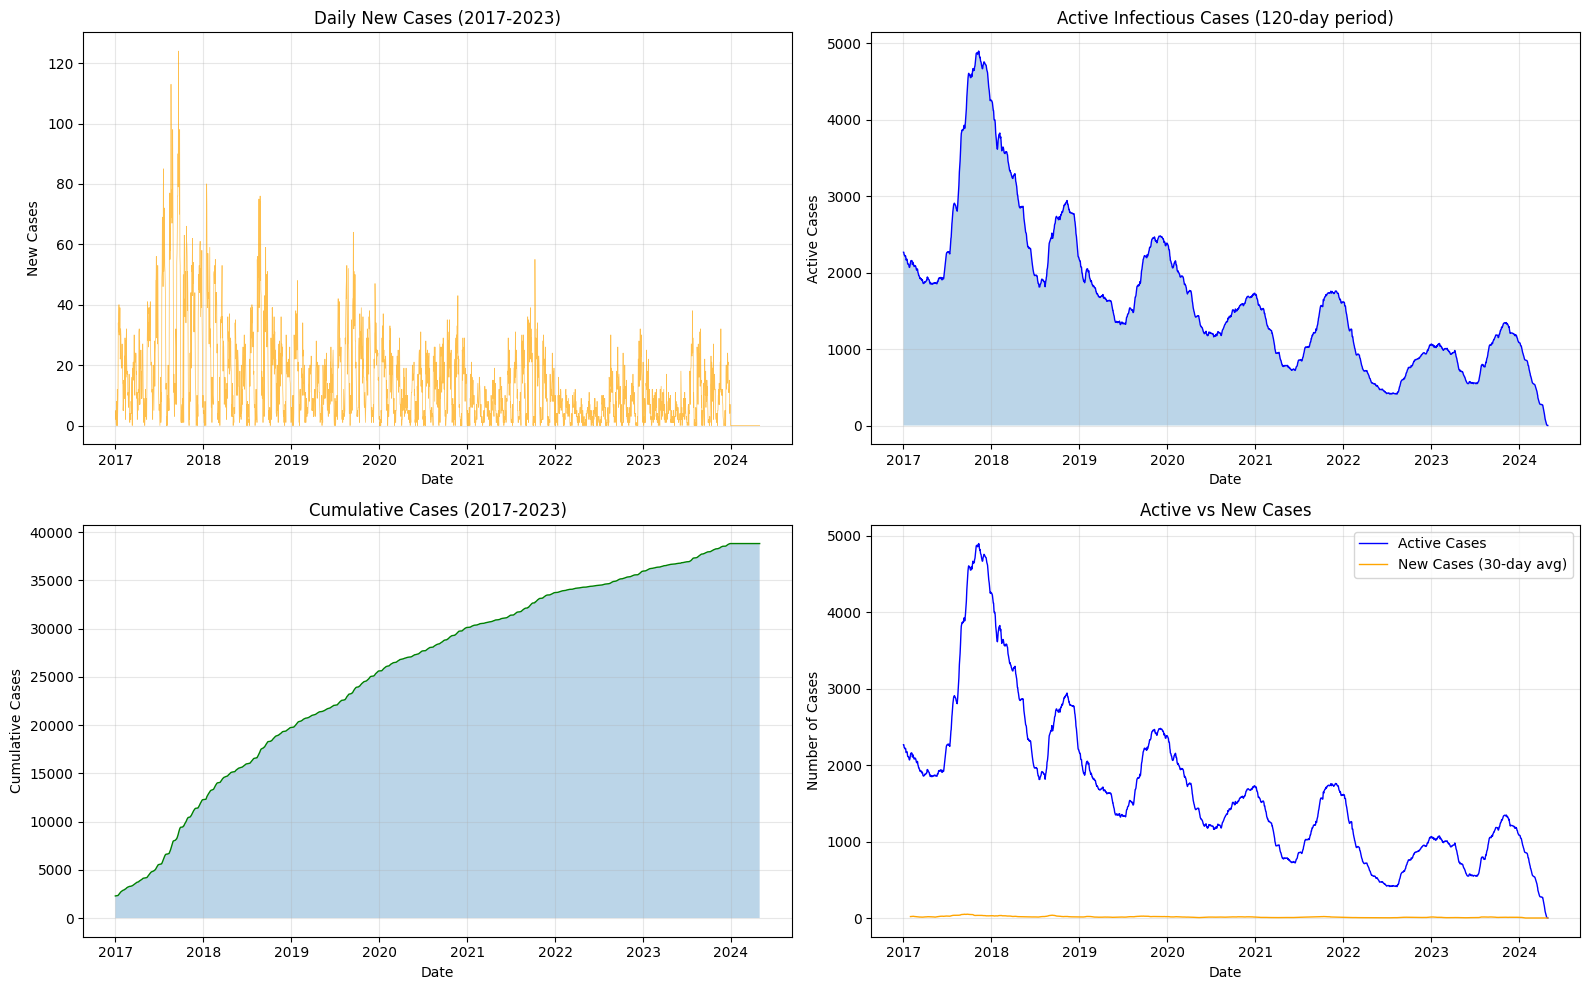

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Daily new cases
axes[0, 0].plot(final_df_2017_2023['date'], final_df_2017_2023['new_cases'], color='orange', linewidth=0.5, alpha=0.7)
axes[0, 0].set_title('Daily New Cases (2017-2023)', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('New Cases')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Active cases
axes[0, 1].plot(final_df_2017_2023['date'], final_df_2017_2023['active_total'], color='blue', linewidth=1)
axes[0, 1].fill_between(final_df_2017_2023['date'], 0, final_df_2017_2023['active_total'], alpha=0.3)
axes[0, 1].set_title('Active Infectious Cases (120-day period)', fontsize=12)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Active Cases')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Cumulative cases
axes[1, 0].plot(final_df_2017_2023['date'], final_df_2017_2023['cumulative_cases'], color='green', linewidth=1)
axes[1, 0].fill_between(final_df_2017_2023['date'], 0, final_df_2017_2023['cumulative_cases'], alpha=0.3)
axes[1, 0].set_title('Cumulative Cases (2017-2023)', fontsize=12)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Cumulative Cases')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Active vs New Cases (with rolling average)
axes[1, 1].plot(final_df_2017_2023['date'], final_df_2017_2023['active_total'], label='Active Cases', color='blue', linewidth=1)
axes[1, 1].plot(final_df_2017_2023['date'], final_df_2017_2023['new_cases'].rolling(30).mean(), 
                label='New Cases (30-day avg)', color='orange', linewidth=1)
axes[1, 1].set_title('Active vs New Cases', fontsize=12)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Number of Cases')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
final_df_2017_2023

,date,active_total,active_symptomatic,active_asymptomatic,new_cases,cumulative_cases,year,month,week,day_of_year,active_per_new_case
0,2017-01-01,2266,1956,310,2,2286,2017,1,52,1,755.333333
1,2017-01-02,2267,1955,312,4,2290,2017,1,1,2,453.400000
2,2017-01-03,2247,1944,303,5,2295,2017,1,1,3,374.500000
3,2017-01-04,2229,1929,300,1,2296,2017,1,1,4,1114.500000
4,2017-01-05,2228,1928,300,0,2296,2017,1,1,5,2228.000000
...,...,...,...,...,...,...,...,...,...,...,...
2671,2024-04-25,9,9,0,0,38813,2024,4,17,116,9.000000
2672,2024-04-26,2,2,0,0,38813,2024,4,17,117,2.000000
2673,2024-04-27,0,0,0,0,38813,2024,4,17,118,0.000000
2674,2024-04-28,0,0,0,0,38813,2024,4,17,119,0.000000


=== YEARLY MALARIA CASES ===

 DT_NOTIF  total_cases
     2003        52434
     2004        41387
     2005        49986
     2006        31860
     2007        34802
     2008        15448
     2009        13124
     2010        11667
     2011        11638
     2012         7789
     2013         4775
     2014         4998
     2015         7644
     2016         7381
     2017         9976
     2018         7491
     2019         5853
     2020         4517
     2021         3611
     2022         2206
     2023         2883


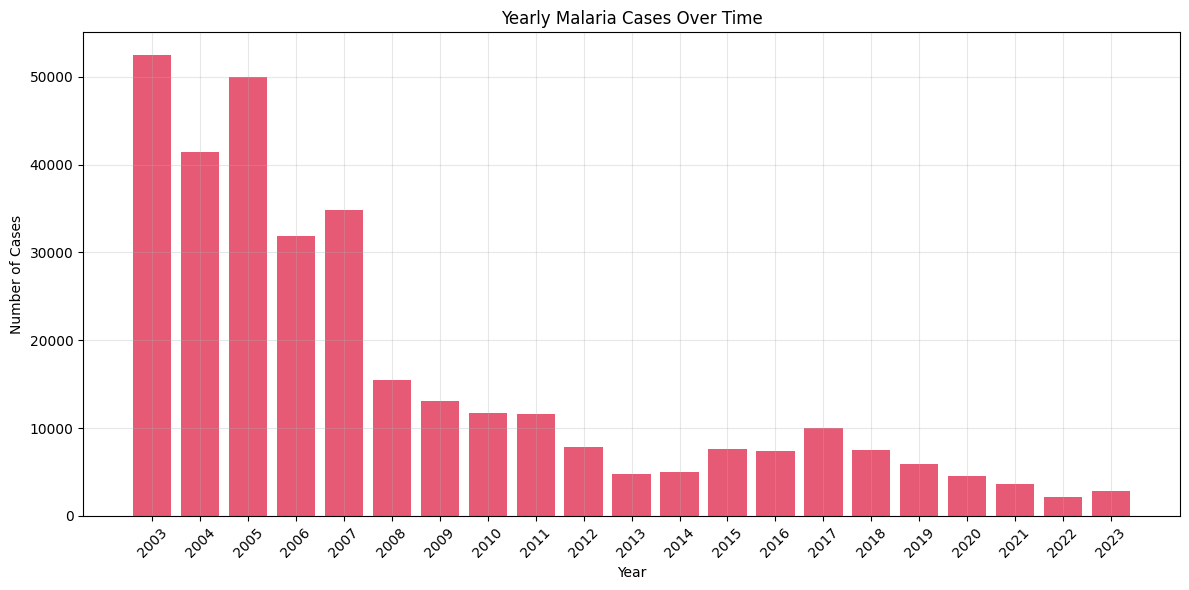

In [25]:
manaus_malaria_data['DT_NOTIF'] = pd.to_datetime(manaus_malaria_data['DT_NOTIF'])
yearly_cases = manaus_malaria_data.groupby(manaus_malaria_data['DT_NOTIF'].dt.year).size().reset_index(name='total_cases')

print("=== YEARLY MALARIA CASES ===\n")
print(yearly_cases.to_string(index=False))

# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(yearly_cases['DT_NOTIF'], yearly_cases['total_cases'], color='crimson', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.title('Yearly Malaria Cases Over Time')
plt.xticks(yearly_cases['DT_NOTIF'], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
manaus_malaria_data['DT_NOTIF'] = pd.to_datetime(manaus_malaria_data['DT_NOTIF'])
manaus_malaria_data['year'] = manaus_malaria_data['DT_NOTIF'].dt.year

years_2004_2008 = list(range(2004, 2009))
years_2015_2019 = list(range(2015, 2020))

cases_2004_2008 = manaus_malaria_data[manaus_malaria_data['year'].isin(years_2004_2008)].shape[0]
cases_2015_2019 = manaus_malaria_data[manaus_malaria_data['year'].isin(years_2015_2019)].shape[0]

print(f"Cases 2004-2008: {cases_2004_2008:,}")
print(f"Cases 2015-2019: {cases_2015_2019:,}")

Cases 2004-2008: 173,483
Cases 2015-2019: 38,345
